In [121]:
# importing necessary functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB
None


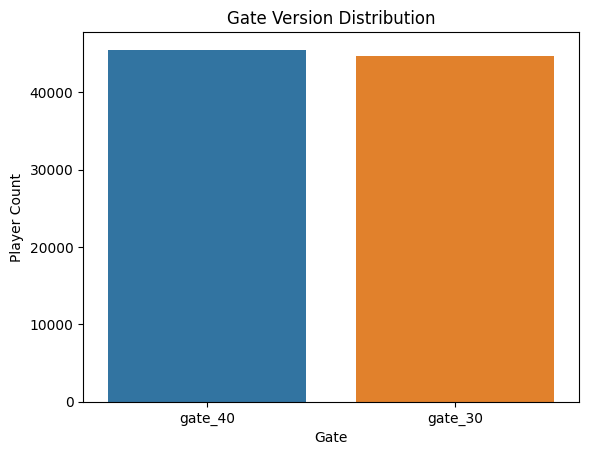

Gate 40 Player Count: 45489
Gate 30 Player Count: 44700


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


In [122]:
# importing and initial viewing of data
df = pd.read_csv('cookie_cats.csv', index_col=False)
print(df.info())
sns.barplot(data=df['version'].value_counts().reset_index(),
            x='version',
            y='count')
plt.title("Gate Version Distribution")
plt.ylabel("Player Count")
plt.xlabel("Gate")
plt.show()
print(f"Gate 40 Player Count: {len(df[df['version'] == 'gate_40'])}")
print(f"Gate 30 Player Count: {len(df[df['version'] == 'gate_30'])}")
df

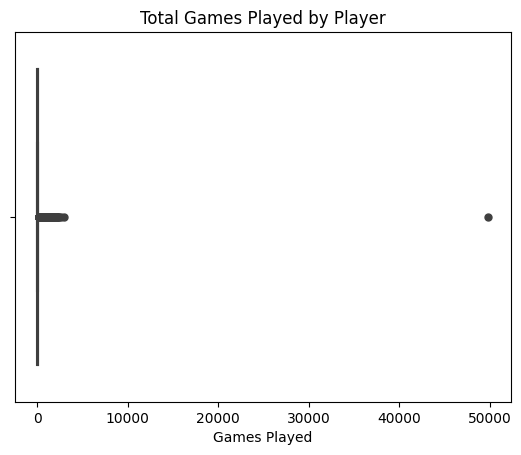

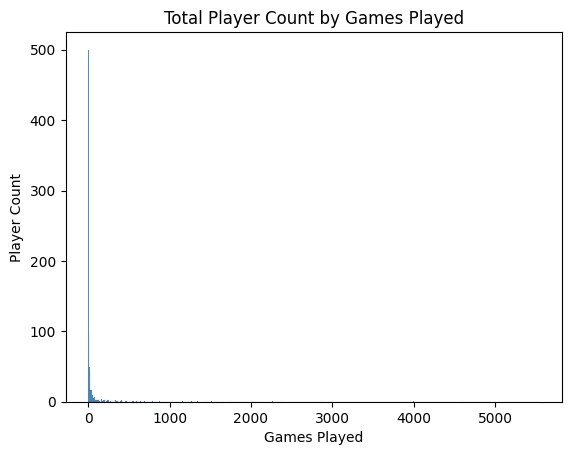

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

In [123]:
# plotting total games played by player
sns.boxplot(data = df,
            x = 'sum_gamerounds',
            flierprops={'marker': "o"})
plt.title("Total Games Played by Player")
plt.xlabel("Games Played")
plt.show()
# plotting total player count by games played for the first 100 games played
sns.histplot(data=df.groupby('sum_gamerounds')['userid'].count())
plt.title("Total Player Count by Games Played")
plt.ylabel("Player Count")
plt.xlabel("Games Played")
plt.show()
df['sum_gamerounds'].describe()

Data Cleaning
---

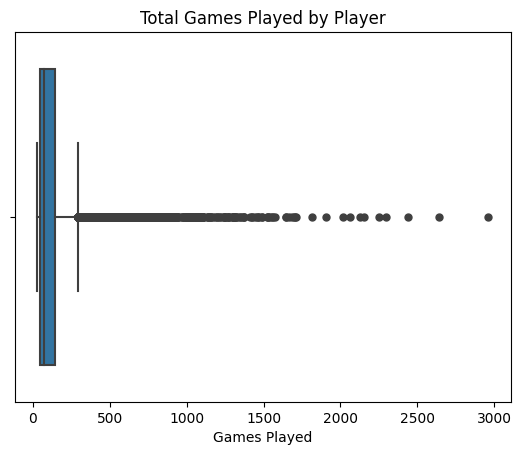

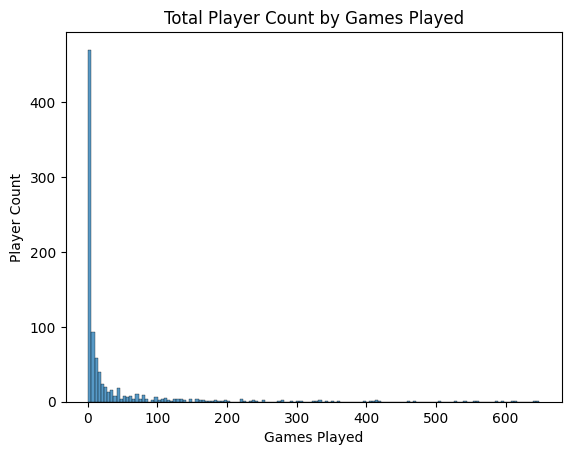

Gate 40 >30 Games Player Count: 16613
Gate 30 >30 Games Player Count: 16655


In [124]:
# removing players with gamerounds < 30 and > 10,0000
df = df.loc[(df['sum_gamerounds'] < 10000) & (df['sum_gamerounds'] >= 30), :].reset_index(drop=True)
# plotting total games played by player
sns.boxplot(data = df,
            x = 'sum_gamerounds',
            flierprops={'marker': "o"})
plt.title("Total Games Played by Player")
plt.xlabel("Games Played")
plt.show()
# plotting total player count by games played for the first 100 games played
sns.histplot(data=df.groupby('sum_gamerounds')['userid'].count())
plt.title("Total Player Count by Games Played")
plt.ylabel("Player Count")
plt.xlabel("Games Played")
plt.show()
# how many people played more than 30 games
print(f"Gate 40 >30 Games Player Count: {len(df[df['version'] == 'gate_40'])}")
print(f"Gate 30 >30 Games Player Count: {len(df[df['version'] == 'gate_30'])}")

1 Day Retention
---

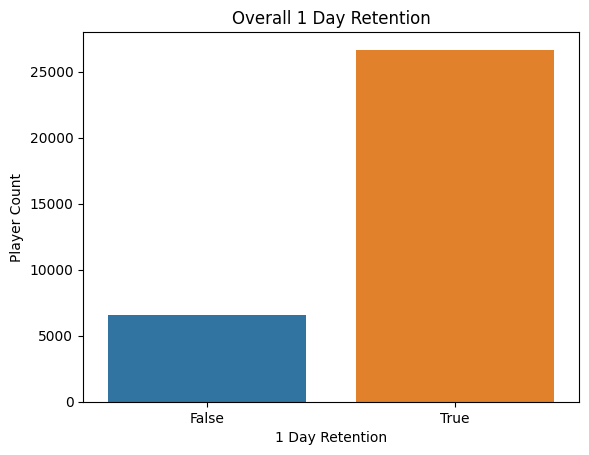

gate_40 1 Day Retention: 13321
gate_30 1 Day Retention: 13341


In [125]:
# plotting 1 day retention rates
one_day_ret = df['retention_1'].value_counts().reset_index()
sns.barplot(data=one_day_ret,
            x='retention_1',
            y='count')
plt.title("Overall 1 Day Retention")
plt.ylabel("Player Count")
plt.xlabel("1 Day Retention")
plt.show()
for gate in ['gate_40', 'gate_30']:
    one_day_ret = df.loc[(df['version'] == gate) & (df['retention_1'] == True),'retention_1'].value_counts().reset_index()
    print(f"{gate} 1 Day Retention: {one_day_ret['count'].sum()}")

In [126]:
# 2 sided, 2 sample z test for proportions 1 day retention
gate_40_ret = len(df[(df['version'] == "gate_40") & (df['retention_1'] == True)])
gate_40_total = len(df[df['version'] == "gate_40"])
gate_30_ret = len(df[(df['version'] == "gate_30") & (df['retention_1'] == True)])
gate_30_total = len(df[df['version'] == "gate_30"])
z_score, p_value = proportions_ztest([gate_30_ret, gate_40_ret], [gate_30_total, gate_40_total])
print(f"z score: {z_score:.4f}\np value: {p_value:.4f}")

z score: -0.1877
p value: 0.8511


7 Day Retention
---

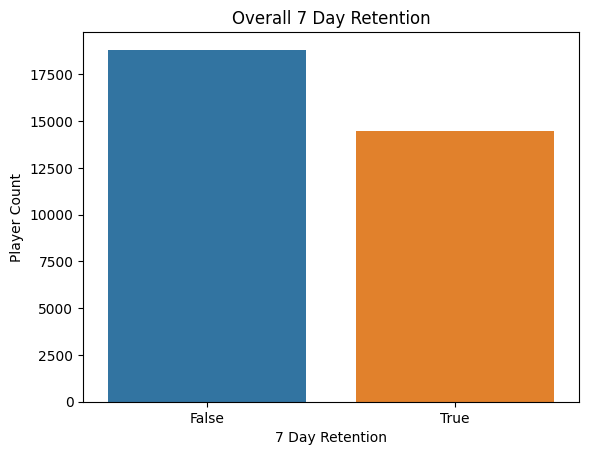

gate_40 7 Day Retention Number: 6028
gate_30 7 Day Retention Number: 6145


In [127]:
# plotting 7 day retention rates
sev_day_ret = df['retention_7'].value_counts().reset_index()
sns.barplot(data=sev_day_ret,
            x='retention_7',
            y='count')
plt.title("Overall 7 Day Retention")
plt.ylabel("Player Count")
plt.xlabel("7 Day Retention")
plt.show()
for gate in ['gate_40', 'gate_30']:
    sev_day_ret = df.loc[(df['version'] == gate) & (df['retention_1'] == True),'retention_7'].value_counts().reset_index()
    print(f"{gate} 7 Day Retention Number: {(sev_day_ret.loc[sev_day_ret['retention_7'] == True, 'count'].iloc[0])}")

In [128]:
# 2 sided, 2 sample z test for proportions 7 day retention
gate_40_ret = len(df[(df['version'] == "gate_40") & (df['retention_7'] == True)])
gate_40_total = len(df[df['version'] == "gate_40"])
gate_30_ret = len(df[(df['version'] == "gate_30") & (df['retention_7'] == True)])
gate_30_total = len(df[df['version'] == "gate_30"])
z_score, p_value = proportions_ztest([gate_30_ret, gate_40_ret], [gate_30_total, gate_40_total])
print(f"z score: {z_score:.4f}\np value: {p_value:.4f}")

z score: 1.6011
p value: 0.1093
